In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [9]:
import torch
import torch.nn as nn

class Model(nn.Module):

    def __init__(self, num_features):

        super().__init__()
        self.linear = nn.Linear(num_features, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, features):

        out = self.linear(features)
        out = self.sigmoid(out)

        return out

# a neural network with one single neuron is created with one output

In [10]:
features = torch.rand(10, 5)
model = Model(features.shape[1])
model(features)

tensor([[0.5635],
        [0.5682],
        [0.5567],
        [0.5108],
        [0.5810],
        [0.5314],
        [0.5213],
        [0.5442],
        [0.5559],
        [0.6191]], grad_fn=<SigmoidBackward0>)

In [12]:
model.linear.weight

Parameter containing:
tensor([[-0.1200, -0.2453, -0.1542,  0.0635,  0.2969]], requires_grad=True)

In [13]:
model.linear.bias

Parameter containing:
tensor([0.3077], requires_grad=True)

In [14]:
!pip install torchinfo

In [15]:
from torchinfo import summary

summary(model, input_size = (10,5))

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [10, 1]                   --
├─Linear: 1-1                            [10, 1]                   6
├─Sigmoid: 1-2                           [10, 1]                   --
Total params: 6
Trainable params: 6
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

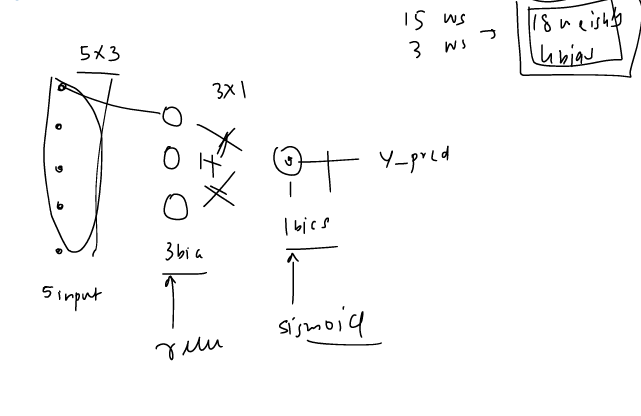

will create this neural network now

In [16]:
class Model1(nn.Module):
    def __init__(self, num_features):
        
        super().__init__()
        
        self.linear1 = nn.Linear(num_features, 3)
        self.relu = nn.ReLU()
        self.linear2 = nn.Linear(3, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, features):
        out = self.linear1(features)
        out = self.relu(out)
        out = self.linear2(out)
        out = self.sigmoid(out)

        return out

In [19]:
model = Model1(features.shape[1])
model(features)

tensor([[0.4738],
        [0.4689],
        [0.4471],
        [0.4876],
        [0.4519],
        [0.4872],
        [0.4749],
        [0.4439],
        [0.4613],
        [0.4641]], grad_fn=<SigmoidBackward0>)

In [21]:
model.linear1.weight

Parameter containing:
tensor([[-0.3177,  0.3420, -0.2969,  0.1858, -0.2320],
        [-0.1023,  0.1072, -0.2332,  0.1724,  0.3881],
        [ 0.0084,  0.2815,  0.3600, -0.4132,  0.2609]], requires_grad=True)

In [22]:
model.linear1.bias

Parameter containing:
tensor([ 0.2993, -0.2774, -0.0371], requires_grad=True)

In [23]:
model.linear2.weight

Parameter containing:
tensor([[-0.2001,  0.0035,  0.2368]], requires_grad=True)

In [24]:
model.linear2.bias

Parameter containing:
tensor([-0.1570], requires_grad=True)

# using sequential container

In [26]:
class Model2(nn.Module):
    def __init__(self, num_features):
        
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(num_features, 3),
            nn.ReLU(),
            nn.Linear(3, 1),
            nn.Sigmoid()
        )

    def forward(self, features):
        out = self.network(features)
        
        return out

In [27]:
model = Model2(features.shape[1])
model(features)

tensor([[0.2851],
        [0.2835],
        [0.3307],
        [0.3053],
        [0.3006],
        [0.2552],
        [0.3200],
        [0.3338],
        [0.3121],
        [0.2714]], grad_fn=<SigmoidBackward0>)

# applying on a real dataset

In [28]:
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [29]:
df = pd.read_csv('https://raw.githubusercontent.com/gscdit/Breast-Cancer-Detection/refs/heads/master/data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [30]:
df.shape

(569, 33)

In [31]:
df.drop(columns=['id', 'Unnamed: 32'], inplace= True)

In [32]:
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, 1:], df.iloc[:, 0], test_size=0.2)

In [33]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [34]:
X_train

array([[-0.08586005,  0.35646642, -0.1040969 , ..., -0.71297222,
        -1.07572654,  0.03948248],
       [-0.47713255, -0.44537639, -0.48145807, ..., -0.15936276,
         0.18382401, -0.40730536],
       [ 0.93983286,  0.03005254,  0.9214995 , ...,  1.17170368,
         0.01235848, -0.29654929],
       ...,
       [ 1.50158837,  2.26527808,  1.67055332, ...,  1.17470834,
        -0.1639145 ,  0.87714246],
       [-0.71469085, -0.23959372, -0.64624991, ...,  0.38598387,
        -0.41710659,  0.45777482],
       [-0.62805194, -1.95917993, -0.65596737, ..., -0.70831499,
        -0.73760292, -0.62182804]])

In [35]:
y_train

544    B
497    B
201    M
501    M
9      M
      ..
148    B
177    M
256    M
469    B
401    B
Name: diagnosis, Length: 455, dtype: object

In [36]:
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

In [37]:
y_train

array([0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1,

In [38]:
y_test

array([0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 1])

In [47]:
X_train_tensor = torch.from_numpy(X_train).float()
X_test_tensor = torch.from_numpy(X_test).float()
y_train_tensor = torch.from_numpy(y_train).float()
y_test_tensor = torch.from_numpy(y_test).float()

In [48]:
X_train_tensor.shape

torch.Size([455, 30])

In [49]:
y_train_tensor.shape

torch.Size([455])

In [50]:
class MySimpleNN(nn.Module):

    def __init__(self,num_features):
        super().__init__()
        self.linear = nn.Linear(num_features, 1)
        self.sigmoid = nn.Sigmoid()
        

    def forward(self, features):
        out = self.linear(features)
        out = self.sigmoid(out)

        return out

    def loss_function(self, y_pred, y):
        # Clamp predictions to avoid log(0)
        epsilon = 1e-7
        y_pred = torch.clamp(y_pred, epsilon, 1 - epsilon)

        # Calculate loss
        loss = -(y_train_tensor * torch.log(y_pred) + (1 - y_train_tensor) * torch.log(1 - y_pred)).mean()
        return loss

In [51]:
learning_rate = 0.1
epochs = 25

In [60]:
loss_function = nn.BCELoss()

In [61]:
#create model
model = MySimpleNN(X_train_tensor.shape[1])
#define loop
for epoch in range(epochs):
    
    #forward pass
    y_pred = model(X_train_tensor)
    
    #loss calculate
    loss = model.loss_function(y_pred, y_train_tensor)
    
    #backward pass
    loss.backward()
    
    # parameters update
    with torch.no_grad():
        model.linear.weight -= learning_rate * model.linear.weight.grad
        model.linear.bias -= learning_rate * model.linear.bias.grad

    # zero gradients
    model.linear.weight.grad.zero_()
    model.linear.bias.grad.zero_()

    # print loss in each epoch
    print(f'Epoch: {epoch + 1}, Loss: {loss.item()}')

Epoch: 1, Loss: 0.7258591055870056
Epoch: 2, Loss: 0.7097328305244446
Epoch: 3, Loss: 0.7002763748168945
Epoch: 4, Loss: 0.6944567561149597
Epoch: 5, Loss: 0.6905856728553772
Epoch: 6, Loss: 0.6877791881561279
Epoch: 7, Loss: 0.6855844855308533
Epoch: 8, Loss: 0.6837682723999023
Epoch: 9, Loss: 0.6822065711021423
Epoch: 10, Loss: 0.6808302402496338
Epoch: 11, Loss: 0.6795981526374817
Epoch: 12, Loss: 0.6784839630126953
Epoch: 13, Loss: 0.6774688363075256
Epoch: 14, Loss: 0.6765392422676086
Epoch: 15, Loss: 0.6756843328475952
Epoch: 16, Loss: 0.6748955249786377
Epoch: 17, Loss: 0.6741655468940735
Epoch: 18, Loss: 0.6734884977340698
Epoch: 19, Loss: 0.6728589534759521
Epoch: 20, Loss: 0.6722726225852966
Epoch: 21, Loss: 0.671725332736969
Epoch: 22, Loss: 0.6712141036987305
Epoch: 23, Loss: 0.670735239982605
Epoch: 24, Loss: 0.6702867746353149
Epoch: 25, Loss: 0.6698659062385559


In [62]:
# model evaluation
with torch.no_grad():
  y_pred = model.forward(X_test_tensor)
  y_pred = (y_pred > 0.5).float()
  accuracy = (y_pred == y_test_tensor).float().mean()
  print(f'Accuracy: {accuracy.item()}')

Accuracy: 0.6246537566184998
